In [12]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


CUDA available: True
Device: Tesla T4


In [13]:


from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import sys
from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/image_realness_project")
sys.path.insert(0, str(PROJECT))

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [15]:
from core.models.joint_model import JointModel

joint_model = JointModel(use_pretrained_backbones=True).to(device)
state = torch.load(PROJECT / "checkpoints" / "JOINT_2024.pth", map_location=device)
joint_model.load_state_dict(state)
joint_model.eval()
print("JOINT loaded")

JOINT loaded


In [16]:
from core.guidance.rationality_guidance import RationalityGuidanceScorer

scorer = RationalityGuidanceScorer(joint_model, image_size=224, blur_kernel=11).to(device)
scorer.eval()

RationalityGuidanceScorer(
  (joint_model): JointModel(
    (technical_feature_extraction): SwinTransformer(
      (features): Sequential(
        (0): Sequential(
          (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        )
        (1): Sequential(
          (0): SwinTransformerBlock(
            (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (attn): ShiftedWindowAttention(
              (qkv): Linear(in_features=96, out_features=288, bias=True)
              (proj): Linear(in_features=96, out_features=96, bias=True)
            )
            (stochastic_depth): StochasticDepth(p=0.0, mode=row)
            (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (mlp): MLP(
              (0): Linear(in_features=96, out_features=384, bias=True)
              (1): GELU(approximate='none')
              (2): Dropout(p=0.0, inplace=False)
  

In [17]:
from core.generation.sd_generator import load_sd_pipeline

pipe = load_sd_pipeline(project=PROJECT, device=device.type)
pipe.safety_checker = None   # skip for speed
print("SD loaded")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

SD loaded


In [18]:
# tweak these
PROMPT              = "a golden retriever in a sunlit meadow"
NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE      = 7.5
RATIONALITY_WEIGHT  = 0.05   # increase if effect too weak, decrease if images degrade
GUIDANCE_LAST_STEPS = 20        # only guide the last N denoising steps
SEED                = 42
OUTPUT_DIR          = PROJECT / "outputs" / "images" / "rationality_guided"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [19]:
# run — this is the generate_with_rationality_guidance script as a function call
import subprocess, sys

result = subprocess.run([
    sys.executable,
    str(PROJECT / "scripts" / "generate_with_rationality_guidance.py"),
    "--project",              str(PROJECT),
    "--prompt",               PROMPT,
    "--output-dir",           str(OUTPUT_DIR),
    "--num-inference-steps",  str(NUM_INFERENCE_STEPS),
    "--guidance-scale",       str(GUIDANCE_SCALE),
    "--rationality-weight",   str(RATIONALITY_WEIGHT),
    "--guidance-last-steps",  str(GUIDANCE_LAST_STEPS),
    "--seed",                 str(SEED),
], capture_output=False)

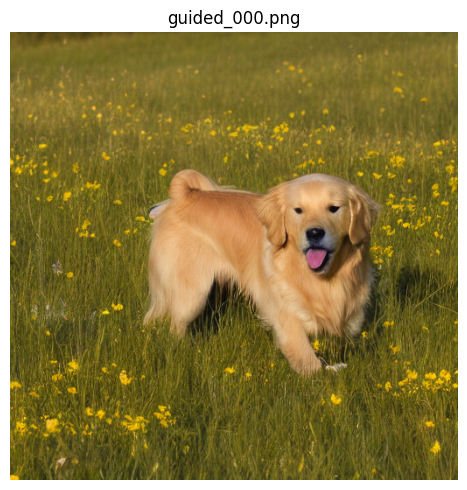

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

images = sorted(OUTPUT_DIR.glob("guided_*.png"))
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
if len(images) == 1:
    axes = [axes]
for ax, p in zip(axes, images):
    ax.imshow(Image.open(p))
    ax.set_title(p.name)
    ax.axis("off")
plt.tight_layout()
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

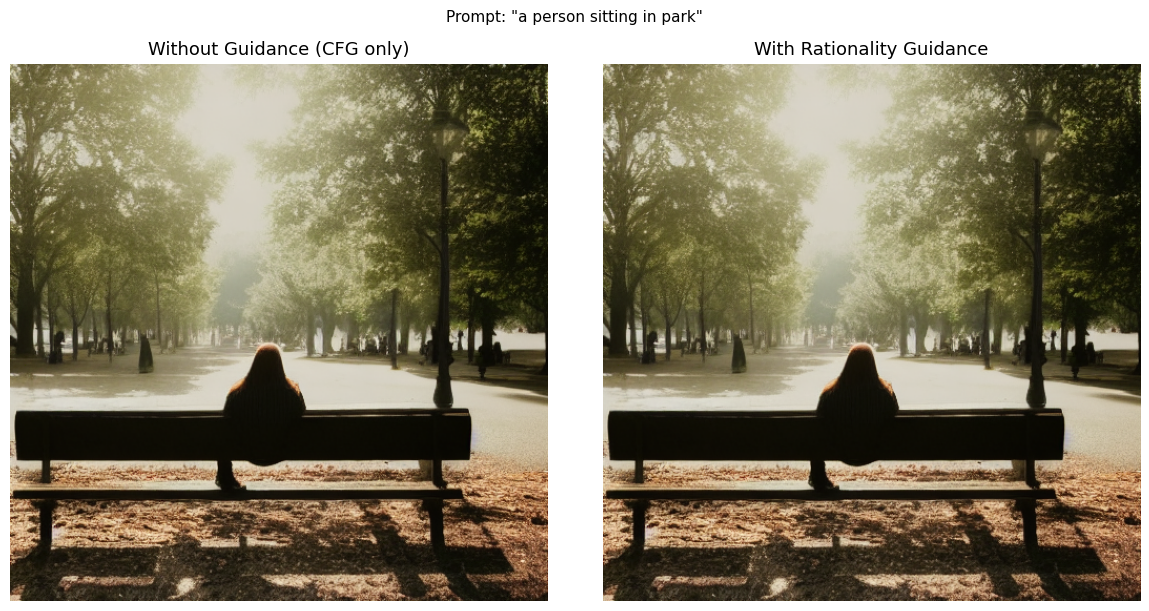

In [21]:
from core.generation.sd_generator import load_sd_pipeline, generate_image
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from PIL import Image

PROMPT = "a person sitting in park"
SEED   = 42  # same seed so the only difference is guidance

# --- without guidance (standard SD) ---
no_guidance_path = PROJECT / "outputs" / "images" / "no_guidance" / "image_000.png"
generate_image(
    pipe=pipe,
    prompt=PROMPT,
    output_path=no_guidance_path,
    guidance_scale=7.5,
    num_inference_steps=30,
    seed=SEED,
)

# --- with rationality guidance (run the script) ---
import subprocess, sys
guided_dir = PROJECT / "outputs" / "images" / "rationality_guided_compare"

subprocess.run([
    sys.executable,
    str(PROJECT / "scripts" / "generate_with_rationality_guidance.py"),
    "--project",             str(PROJECT),
    "--prompt",              PROMPT,
    "--output-dir",          str(guided_dir),
    "--num-inference-steps", "30",
    "--guidance-scale",      "7.5",
    "--rationality-weight",  "0.05",
    "--guidance-last-steps", "15",
    "--seed",                str(SEED),
])

# --- display side by side ---
img_no_guidance = Image.open(no_guidance_path)
img_guided      = Image.open(guided_dir / "guided_000.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_no_guidance)
axes[0].set_title("Without Guidance (CFG only)", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_guided)
axes[1].set_title("With Rationality Guidance", fontsize=13)
axes[1].axis("off")

plt.suptitle(f'Prompt: "{PROMPT}"', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()